# A Discrete Motion Model

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop//Users/jiazhenghao/CodingProjects/research/gtsam/python/gtsam/examples/DiscreteMotionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GTSAM Copyright 2010-2022, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [57]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

*For further information on theories and implementations, refer to the robotics book: [https://www.roboticsbook.org/](https://www.roboticsbook.org/)*


In this notebook, we walk through an simple example of: 
1. Representing discrete random variables in gtsam
2. Building a bayes net with the discrete random variables
3. Visualizing the bayes net we built
4. Doing effecient inference with gtsam FactorGraphs (reducing the inference time from exponential to polynomial)!

## Other Installs and Imports

Some of the visualizations below use [graphviz](https://graphviz.org/). That is not super easy to install except when using conda, in which case it is a one-liner:
```bash
conda install -c conda-forge python-graphviz
```
It is also installed by default on Colab.

In [58]:
try:
    import google.colab
    %pip install -U -q gtbook # this installs more visualization mojo, but needs graphviz!
except ImportError:
    pass

In [59]:
import gtsam
import gtbook
from gtbook import display

## Representing Discrete Random Variables

For this simple example, think of a Robot that is moving between different rooms for several seconds. After 1, 2, 3, ... n seconds, the robot wouldn't be sure where it is any more. So for each timestamp t (1,2,3, ...n), we use a random variable $X_t$ to represent the probability of the robot in each room.

We have only 5 rooms `['Living Room', 'Kitchen', 'Office', 'Hallway', 'Dining Room']` variable X can take on. So each $X_t$ is a probability distribution over these 5 states. Let's represent that in gtsam. 


<figure id="fig:House">
<img src="https://github.com/gtbook/robotics/blob/main/Figures3/S31-House.png?raw=1" alt="" />
<figcaption>The floor plan of a house in which our hypothetical vacuum cleaning robot will operate.</figcaption>
</figure>


In [60]:
# We want to create random variables X1, X2, X3, ...
from gtbook.discrete import Variables
VARIABLES = Variables()

# The possible states of the random variable
room_states = ['Living Room', 'Kitchen', 'Office', 'Hallway', 'Dining Room']

# create a discrete variable with states

#                   name,    states
X1 = VARIABLES.discrete('X1', room_states)
X2 = VARIABLES.discrete('X2', room_states)
X3 = VARIABLES.discrete('X3', room_states)
X4 = VARIABLES.discrete('X4', room_states)

print(X1)
print(X4)

(0, 5)
(3, 5)


We have just created random variables $X1, X2, X3, X4$. Each one is a discrete variable that has probability of being in each of the room_states. 

The printed output we see for X1 and X2 is a tuple (key, cardinality). The key is the gtsam internal representation of the variable. Cardinality in our case is just the number of rooms: 5. 

At any time, if you are confused about how to use a function or how to interpret the result, you can run

In [61]:
help(VARIABLES.discrete)

Help on method discrete in module gtbook.discrete:

discrete(name: str, domain: list[str]) -> tuple[int, int] method of gtbook.discrete.Variables instance
    Create a variable with given name and discrete domain of named values.

    Args:
        name (str): name of the variable.
        domain (list[str]): names for the different values.

    Returns:
        DiscreteKey, i.e., (gtsam.Key, cardinality)



#### Discrete Series
In the previous example, it's a bit tedious to create each variable one by one. We can use `gtsam.Variables.discrete_series` to create a series of discrete variables with the same cardinality.

In [62]:
X = VARIABLES.discrete_series('X', range(1, 5), room_states)
print(X)
print(f"X1: {X[1]}")
print(f"X4: {X[4]}")

{1: (6341068275337658369, 5), 2: (6341068275337658370, 5), 3: (6341068275337658371, 5), 4: (6341068275337658372, 5)}
X1: (6341068275337658369, 5)
X4: (6341068275337658372, 5)


Here, we see the keys got much longer, but the object is really exactly the same as what we had above. For more details on how this value is constructed, see [here](https://www.roboticsbook.org/S31_vacuum_state.html#gtsam-101). 



### Assigning Probabilities
We can now assign probabilities to each variable. Let's initialize X1 to be in the Living Room with 80% probability, and the rest of the rooms with 5% probability each.

1. Create a Graph `gtsam.DiscreteFactorGraph` to record the assignments. 
2. Add the variables to the graph with the assigned probabilities.

*Don't get frustrated by the term `FactorGraph`, it's just a graph that holds variables and their probabilities. To learn more about FactorGraphs, and how we use it to perform optimization, view the [roboticsbook](https://www.roboticsbook.org/S34_vacuum_perception.html#converting-bayes-nets-into-factor-graphs) and the [gtsam documentation](https://borglab.github.io/gtsam/discretefactorgraph/).*

<!-- TODO: Are there better ways to remove variables?  -->

In [63]:
# create graph
graph = gtsam.DiscreteFactorGraph()

# adding probabilities for X1
# X = ['Living Room', 'Kitchen', 'Office', 'Hallway', 'Dining Room']
prob = [0.8, 0.05, 0.05, 0.05, 0.05]  # P(X1)
graph.add(X[1], prob)  # P(X1)


In [64]:
# Let's view the assignments by printing the graph: 

def pretty(obj):
    return gtbook.display.pretty(obj, VARIABLES) # function to display 

pretty(graph)

X1,value
Living Room,0.8
Kitchen,0.05
Office,0.05
Hallway,0.05
Dining Room,0.05


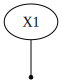

In [65]:
# This cell won't run if you don't have graphviz installed!
display.show(graph)

In [66]:
# Alternatively, you can also specify the probabilities in string format!
# Plus, they don't have to sum to 1, gtsam will normalize them for you. So you can also give them in terms of frequency

graph2 = gtsam.DiscreteFactorGraph()
# This works:
# graph2.add(X[1], "0.8 0.05 0.05 0.05 0.05")  # P(X1)

# This also works:
graph2.add(X[1], "80 5 5 5 5")  # P(X1) in terms of frequency

pretty(graph2)

X1,value
Living Room,80
Kitchen,5
Office,5
Hallway,5
Dining Room,5


### Conditional Probability

Let's now move between the rooms! Let's allow the robot to move *up, down, left, right*. And after taking each action, the room X the robot is in change. 
To do this, introduce a new variable $A$ that represent what actions we took, and make next next room the robot with be in $X_{t+1}$, depend (conditional) on the action it takes $A_t$, and where it currently is $X_t$. 

Here we focus on building the **conditional probability**. To learn more about how this simulated robot environment works, visit [robotics-book-ch3](https://www.roboticsbook.org/S30_vacuum_intro.html)

Below is the probability table we want to model. Given, current room X1, action A1, what's the probability of being in each room in X2.
<figure id="fig:House">
<img src="https://raw.githubusercontent.com/borglab/gtsam/refs/heads/develop/doc/images/state_action_cond_prob.png " alt="" />
<figcaption></figcaption>
</figure>

In [67]:
# Great. Let's now represent 

room_states = ['Living Room', 'Kitchen', 'Office', 'Hallway', 'Dining Room']
action_states = ['L', 'R', 'U', 'D'] # Left, Right, Up, Down
# create a discrete variable with states

#                   name,    states
X = VARIABLES.discrete_series('X', range(1, 5), room_states)
A = VARIABLES.discrete_series('A', range(1, 4), action_states)

# conditional probability table for P(X2 | X1, A1)
cond_prob = """
1/0/0/0/0 2/8/0/0/0 1/0/0/0/0 2/0/0/8/0
8/2/0/0/0 0/1/0/0/0 0/1/0/0/0 0/2/0/0/8
0/0/1/0/0 0/0/2/8/0 0/0/1/0/0 0/0/1/0/0
0/0/8/2/0 0/0/0/2/8 8/0/0/2/0 0/0/0/1/0
0/0/0/8/2 0/0/0/0/1 0/8/0/0/2 0/0/0/0/1
"""

conditional = gtsam.DiscreteConditional(X[2], [X[1], A[1]], cond_prob)

# Add the conditional to the graph. Here we use pushback for adding an object with probabilities already specified. (In contrast to add which takes variable and probabilities/frequencies as input)
graph = gtsam.DiscreteFactorGraph()
graph.push_back(conditional)
pretty(graph)

X1,A1,Living Room,Kitchen,Office,Hallway,Dining Room
Living Room,L,1,0,0,0,0
Living Room,R,0.2,0.8,0,0,0
Living Room,U,1,0,0,0,0
Living Room,D,0.2,0,0,0.8,0
Kitchen,L,0.8,0.2,0,0,0
Kitchen,R,0,1,0,0,0
Kitchen,U,0,1,0,0,0
Kitchen,D,0,0.2,0,0,0.8
Office,L,0,0,1,0,0
Office,R,0,0,0.2,0.8,0


It is also possible to represent the probabilities as a list/array to `gtsam.DiscreteConditional`. 

We just need to make sure to force cast the arguments be `key: tuple[int, int], parents: gtsam.gtsam.DiscreteKeys, table: list[float]`

In [68]:
cpt = [
    [1, 0, 0, 0, 0], [2, 8, 0, 0, 0], [1, 0, 0, 0, 0], [2, 0, 0, 8, 0],
    [8, 2, 0, 0, 0], [0, 1, 0, 0, 0], [0, 1, 0, 0, 0], [0, 2, 0, 0, 8],
    [0, 0, 1, 0, 0], [0, 0, 2, 8, 0], [0, 0, 1, 0, 0], [0, 0, 1, 0, 0],
    [0, 0, 8, 2, 0], [0, 0, 0, 2, 8], [8, 0, 0, 2, 0], [0, 0, 0, 1, 0],
    [0, 0, 0, 8, 2], [0, 0, 0, 0, 1], [0, 8, 0, 0, 2], [0, 0, 0, 0, 1],
]

# flatten cpt and create motion model
flatten_cpt = [item for sublist in cpt for item in sublist]

# force case parents 
parents = gtsam.DiscreteKeys()
parents.push_back(X[1])
parents.push_back(A[1])

motion_model2 = gtsam.DiscreteConditional(key=X[2], parents=parents, table=flatten_cpt)
graph2 = gtsam.DiscreteFactorGraph()
graph2.push_back(motion_model2)
pretty(graph2)

X1,A1,Living Room,Kitchen,Office,Hallway,Dining Room
Living Room,L,1,8,0,0,0
Living Room,R,0,2,0,0,0
Living Room,U,0,0,1,8,0
Living Room,D,0,0,0,2,8
Kitchen,L,0,0,0,0,2
Kitchen,R,2,0,0,0,0
Kitchen,U,8,1,0,0,0
Kitchen,D,0,0,2,0,0
Office,L,0,0,8,2,0
Office,R,0,0,0,8,1


Let's look at how the graph looks like

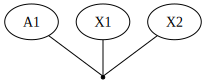

In [69]:
display.show(graph)

# Sampling from Probability Distribution


If we just want a sample with any prior knowledge about our robot's location or actions, simply call `.sample` on the `gtsam.DiscreteFactorGraph` graph. 

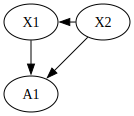

In [70]:
posterior = graph.sumProduct() # Powerful fancy optimization happening here read more at https://www.roboticsbook.org/S34_vacuum_perception.html#sum-product-in-gtsam
display.show(posterior, hints={"X": 1, "A":0})

In [71]:
sample = posterior.sample()
pretty(sample)

Variable,value
A1,U
X1,Office
X2,Office


If we do have some additional knowledge. Say we know that: 
1. robot started in the Living Room with 80% probability, 5% in the rest. So X[1] = [0.8, 0.05, 0.05, 0.05, 0.05]
2. robot took action 'right' at time 1

We can condition on that knowledge and sample again. To do this, we do have to build the graph again to incorporate these knowledge. 

In [72]:
graph = gtsam.DiscreteFactorGraph()

# add information about X1
graph.add(X[1], "80 5 5 5 5")  # P(X1)
# add assignment of A1
actions = VARIABLES.assignment({A[1]: 'R'}) # action A1 = 'R' 
conditional = gtsam.DiscreteConditional(X[2], [X[1], A[1]], cond_prob)
conditional_up = conditional.choose(actions)  # new_conditional probabilities given that A1 = 'R'

graph.push_back(conditional_up)
posterior = graph.sumProduct() # Powerful fancy optimization happening here read more at https://www.roboticsbook.org/S34_vacuum_perception.html#sum-product-in-gtsam
# show(posterior, hints={"X": 1})
sample = posterior.sample()
pretty(sample)

Variable,value
X1,Kitchen
X2,Kitchen


Notice how the variable A[1] is no longer present in our sample. (Since it's always fixed). If we examine `conditional` and `conditional_up`, we can see that we have selected only the rows with A[1] = 'R' and completely removed the column A[1]. 

In [73]:
pretty(conditional)

X1,A1,Living Room,Kitchen,Office,Hallway,Dining Room
Living Room,L,1,0,0,0,0
Living Room,R,0.2,0.8,0,0,0
Living Room,U,1,0,0,0,0
Living Room,D,0.2,0,0,0.8,0
Kitchen,L,0.8,0.2,0,0,0
Kitchen,R,0,1,0,0,0
Kitchen,U,0,1,0,0,0
Kitchen,D,0,0.2,0,0,0.8
Office,L,0,0,1,0,0
Office,R,0,0,0.2,0.8,0


In [74]:
pretty(conditional_up)

X1,Living Room,Kitchen,Office,Hallway,Dining Room
Living Room,0.2,0.8,0,0,0
Kitchen,0,1,0,0,0
Office,0,0,0.2,0.8,0
Hallway,0,0,0,0.2,0.8
Dining Room,0,0,0,0,1


# Congratulations! 
You have built your first discrete bayes net in gtsam, and performed efficient inference with it.